In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binom
np.random.seed(42)
sns.set_style("whitegrid")

[[-0.25091976  0.16155809]
 [ 0.90142861  0.0539433 ]
 [ 0.46398788 -0.2979261 ]
 [ 0.19731697 -0.01357468]
 [-0.68796272 -0.26980673]
 [-0.68801096  0.31586267]
 [-0.88383278  0.6700593 ]
 [ 0.73235229  0.57378887]
 [ 0.20223002 -0.31861515]
 [ 0.41614516  0.01883899]]
Point (-0.251, 0.162) -> inside
Point (0.901, 0.054) -> inside
Point (0.464, -0.298) -> inside
Point (0.197, -0.014) -> inside
Point (-0.688, -0.270) -> inside
Point (-0.688, 0.316) -> inside
Point (-0.884, 0.670) -> outside
Point (0.732, 0.574) -> inside
Point (0.202, -0.319) -> inside
Point (0.416, 0.019) -> inside
inside 78603
outside 21397
Estimated pi 3.14412
True pi 3.141592653589793
Error 0.00252734641020691


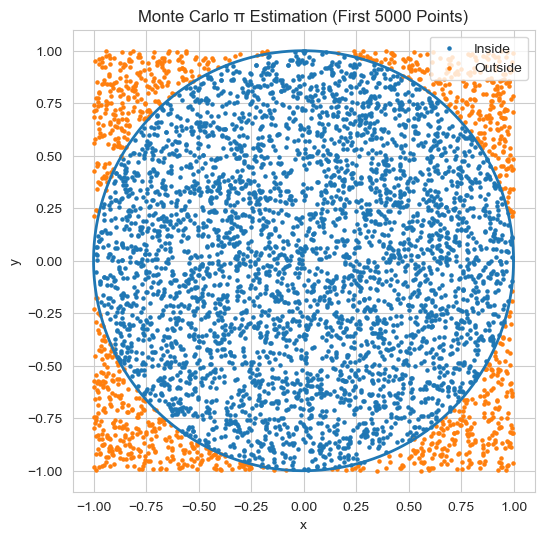

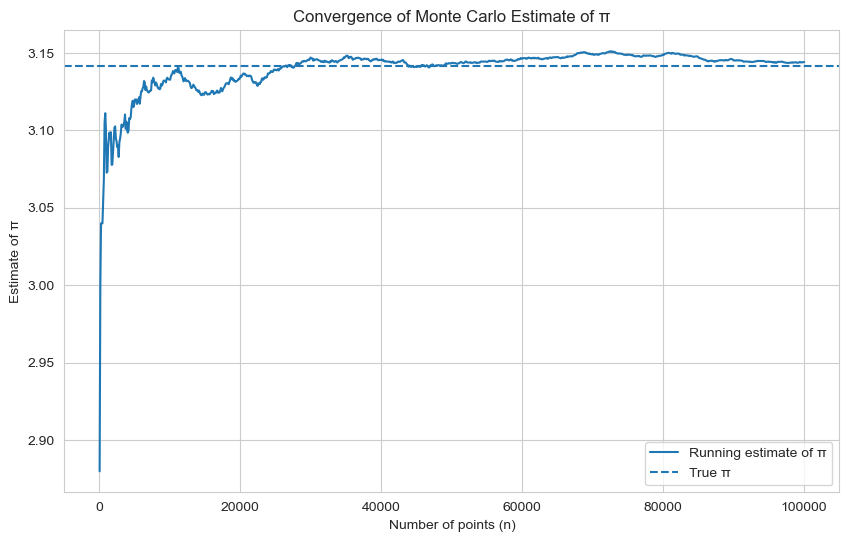

Estimated π at N=100,000: 3.14412
True π: 3.141592653589793
Estimate stabilizes within ±0.01 from about n = 23100


In [30]:
# TASK 1 

# Generate N = 100,000 random (x, y) points where x and y are each drawn from Uniform(−1, 1).
N = 100000
x = np.random.uniform(-1,1,N)
y = np.random.uniform(-1,1,N)
points = np.column_stack((x,y))
print(points[:10])

# Classify each point as "inside" (x² + y² ≤ 1) or "outside" the unit circle.
inside = x**2 + y**2 <=1 
labels = np.where(inside,"inside","outside")
for i in range(10):
    print(f"Point ({x[i]:.3f}, {y[i]:.3f}) -> {labels[i]}")

num_inside = np.sum(inside)
num_outside = N - num_inside
print("inside" , num_inside)
print("outside" , num_outside)

# Estimate π as 4 × (points inside) / N.
pi_estimate = 4 * np.sum(inside) / N
print("Estimated pi" , pi_estimate)

# Print your estimate alongside the true value of π.
pi_true = np.pi
print("True pi" , pi_true)
print("Error",abs(pi_estimate - pi_true))


#Create a scatter plot of the first 5,000 points, coloring inside points differently from outside points. Draw the unit circle on top for reference.
x_plot = x[:5000]
y_plot = y[:5000]
inside_plot = inside[:5000]

plt.figure(figsize=(6,6))

# Plot inside points
plt.scatter(x_plot[inside_plot], y_plot[inside_plot], s=5, label="Inside")

# Plot outside points
plt.scatter(x_plot[~inside_plot], y_plot[~inside_plot], s=5, label="Outside")

# Draw unit circle
theta = np.linspace(0, 2*np.pi, 200)
circle_x = np.cos(theta)
circle_y = np.sin(theta)
plt.plot(circle_x, circle_y, linewidth=2)

# Formatting
plt.gca().set_aspect('equal', adjustable='box')
plt.title("Monte Carlo π Estimation (First 5000 Points)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

step = 100
n_values = np.arange(step, N + 1, step)
cumulative_inside = np.cumsum(inside)
running_pi = 4 * cumulative_inside[n_values - 1] / n_values

# Convergence plot: Compute the running estimate of π after every 100 points (i.e., at n = 100, 200, 300, …, 100,000). 
# Plot this running estimate with a horizontal line at the true π. Add a title and axis labels.
plt.figure(figsize=(10, 6))
plt.plot(n_values, running_pi, label="Running estimate of π")
plt.axhline(np.pi, linestyle="--", label="True π")

plt.title("Convergence of Monte Carlo Estimate of π")
plt.xlabel("Number of points (n)")
plt.ylabel("Estimate of π")
plt.legend()
plt.grid(True)
plt.show()

# Guiding question: At roughly what sample size does your estimate stabilize within ±0.01 of true π?
within_band = np.abs(running_pi - np.pi) <= 0.01

stabilize_n = None
for i in range(len(within_band)):
    if np.all(within_band[i:]):
        stabilize_n = n_values[i]
        break

print("Estimated π at N=100,000:", running_pi[-1])
print("True π:", np.pi)

if stabilize_n is not None:
    print(f"Estimate stabilizes within ±0.01 from about n = {stabilize_n}")
else:
    print("It does not stay within ±0.01 all the way to the end in this run.")

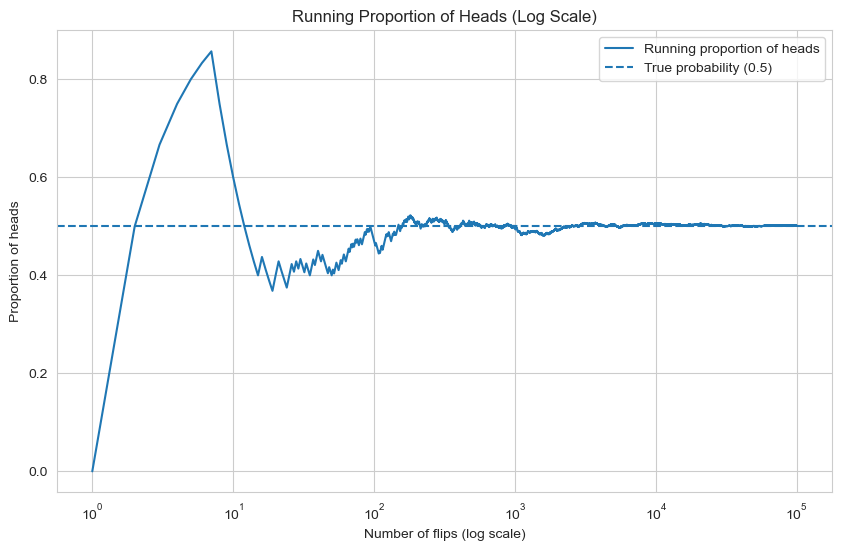

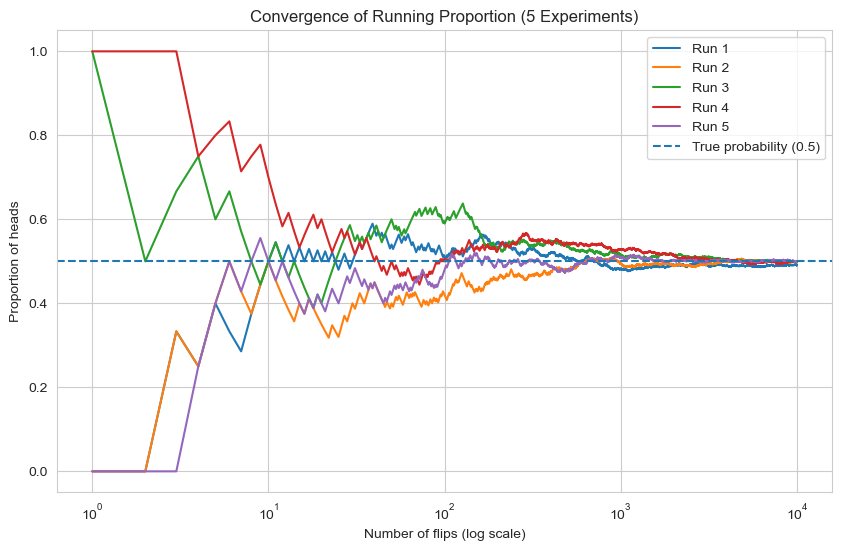

In [31]:
# Simulate 10,000 fair coin flips (use np.random.choice([0, 1]) or np.random.binomial(1, 0.5, size=10000)).
coin_flips = np.random.binomial(1, 0.5, size=10000)

# Compute the running proportion of heads after each flip (cumulative sum divided by cumulative count).
coin_df = pd.DataFrame({"flip": coin_flips})
coin_df["running_heads"] = coin_df["flip"].cumsum()
coin_df["n"] = np.arange(1,len(coin_df) + 1)
coin_df["running_proportion"] = coin_df["running_heads"] / coin_df["n"]
coin_df.head()

# Plot the running proportion with a horizontal line at 0.5. Use a log-scaled x-axis so you can see early fluctuations and later stabilization clearly.
flips = np.random.binomial(1, 0.5, size=N)
running_proportion = np.cumsum(flips) / np.arange(1, N + 1)
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, N + 1), running_proportion, label="Running proportion of heads")
plt.axhline(0.5, linestyle="--", label="True probability (0.5)")
plt.xscale("log")
plt.title("Running Proportion of Heads (Log Scale)")
plt.xlabel("Number of flips (log scale)")
plt.ylabel("Proportion of heads")
plt.legend()
plt.grid(True)
plt.show()

# Repeat the experiment 5 times (5 independent series of 10,000 flips) and overlay all 5 convergence paths on the same plot with different colors.
N = 10000
num_experiments = 5

plt.figure(figsize=(10, 6))

for i in range(num_experiments):
    flips = np.random.binomial(1, 0.5, size=N)
    
    running_proportion = np.cumsum(flips) / np.arange(1, N + 1)
    
    plt.plot(np.arange(1, N + 1), running_proportion, label=f"Run {i+1}")

plt.axhline(0.5, linestyle="--", label="True probability (0.5)")

plt.xscale("log")

plt.title("Convergence of Running Proportion (5 Experiments)")
plt.xlabel("Number of flips (log scale)")
plt.ylabel("Proportion of heads")
plt.legend()
plt.grid(True)

plt.show()



numbers of trying between 10**2 and 10**5  stay within ±0.01 of 0.5.

Average defects: 1.5063
defective_count
0    2135
1    3414
2    2537
3    1283
4     463
5     138
6      26
7       4
Name: count, dtype: int64


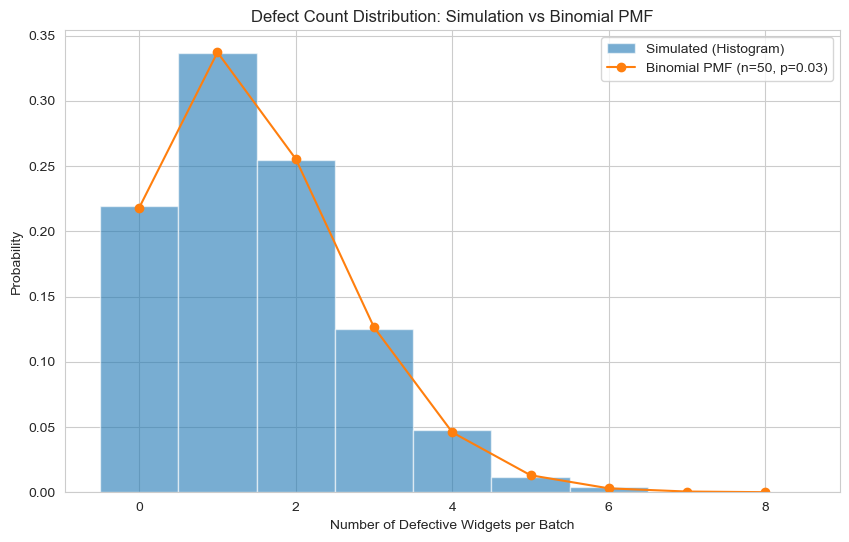

P(0 defects in a batch) ≈ 0.2196
P(3 or more defects in a batch) ≈ 0.1892
Expected defects per batch ≈ 1.4983
P(0 defects):
  Simulation: 0.21960
  Theory:     0.21807

P(3 or more defects):
  Simulation: 0.18920
  Theory:     0.18920

Expected defects:
  Simulation: 1.49830
  Theory:     1.50000


In [32]:
# Task 3

# Simulate 10,000 batches of 50 widgets each, where each widget has a 3% chance of being defective.
num_batches = 10000
batch_size = 50
p_defect = 0.03
defects_per_batch = np.random.binomial(batch_size,p_defect,size=num_batches)
df = pd.DataFrame({
    "batch_id" : np.arange(1,num_batches+1),
    "defective_count" : defects_per_batch})

# For each batch, record the number of defective widgets found.
print("Average defects:", df["defective_count"].mean())
print(df["defective_count"].value_counts().sort_index())

# Plot a histogram of the defect counts across all 10,000 batches. Overlay the theoretical Binomial(n=50, p=0.03) PMF as points connected by a line.
n = 50
p = 0.03
defects = np.random.binomial(n, p, size=num_batches)
plt.figure(figsize=(10, 6))
counts, bins, _ = plt.hist(
    defects,
    bins=np.arange(defects.min(), defects.max() + 2) - 0.5,
    density=True,
    alpha=0.6,
    label="Simulated (Histogram)"
)
k = np.arange(0, defects.max() + 1)
pmf = binom.pmf(k, n, p)

plt.plot(k, pmf, marker='o', linestyle='-', label="Binomial PMF (n=50, p=0.03)")

plt.title("Defect Count Distribution: Simulation vs Binomial PMF")
plt.xlabel("Number of Defective Widgets per Batch")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)

plt.show()


# From your simulation, estimate:
# P(0 defects in a batch)
# P(3 or more defects in a batch)
# The expected number of defects per batch
p_0_defects = np.mean(defects == 0)
p_3_or_more = np.mean(defects >= 3)
expected_defects = np.mean(defects)

print(f"P(0 defects in a batch) ≈ {p_0_defects:.4f}")
print(f"P(3 or more defects in a batch) ≈ {p_3_or_more:.4f}")
print(f"Expected defects per batch ≈ {expected_defects:.4f}")

# Compare each simulation estimate to the theoretical binomial value (use scipy.stats.binom or manual calculation).
p0_sim = np.mean(defects == 0)
p3plus_sim = np.mean(defects >= 3)
mean_sim = np.mean(defects)

p0_theory = binom.pmf(0, n, p)
p3plus_theory = 1 - binom.cdf(2, n, p)
mean_theory = n * p

print("P(0 defects):")
print(f"  Simulation: {p0_sim:.5f}")
print(f"  Theory:     {p0_theory:.5f}\n")

print("P(3 or more defects):")
print(f"  Simulation: {p3plus_sim:.5f}")
print(f"  Theory:     {p3plus_theory:.5f}\n")

print("Expected defects:")
print(f"  Simulation: {mean_sim:.5f}")
print(f"  Theory:     {mean_theory:.5f}")

The empirical estimates are very close to the theoretical binomial values, with only small differences due to randomness in simulation. These differences decrease as the number of simulated batches increases. While 1,000 batches can give a rough approximation, 10,000 batches provide more stable and accurate estimates that better match the theoretical probabilities.